In [1]:
!pip install tcia-utils -q
from tcia_utils import nbia
import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 54.7 MB/s eta 0:00:00


In [2]:

collection = "CMB-MML"
clinical_data = nbia.getSeries(collection = collection)
df = pd.DataFrame(clinical_data)
df.head()

,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDate,SeriesDescription,SeriesNumber,Collection,Site,PatientID,PatientSex,...,DataDescriptionURI,FileSize,ReleasedStatus,DateReleased,StudyDesc,StudyDate,ThirdPartyAnalysis,Authorized,ProtocolName,BodyPartExamined
0,1.3.6.1.4.1.14519.5.2.1.8584863090481711108298...,1.3.6.1.4.1.14519.5.2.1.2341810937770235181967...,MR,09-11-1959,AX T1,6,CMB-MML,IROCOH,MSB-00437,O,...,https://doi.org/10.7937/SZKB-SW39,14309390,Yes,08-28-2024,MRI_LSpine,09-11-1959,NO,1,NaN,NaN
1,1.3.6.1.4.1.14519.5.2.1.4891201330825450932896...,1.3.6.1.4.1.14519.5.2.1.2341810937770235181967...,MR,09-11-1959,SAG T2,3,CMB-MML,IROCOH,MSB-00437,O,...,https://doi.org/10.7937/SZKB-SW39,9008798,Yes,08-28-2024,MRI_LSpine,09-11-1959,NO,1,NaN,NaN
2,1.3.6.1.4.1.14519.5.2.1.1519150416470039219417...,1.3.6.1.4.1.14519.5.2.1.2341810937770235181967...,MR,09-11-1959,SAG T1,5,CMB-MML,IROCOH,MSB-00437,O,...,https://doi.org/10.7937/SZKB-SW39,9009006,Yes,08-28-2024,MRI_LSpine,09-11-1959,NO,1,NaN,NaN
3,1.3.6.1.4.1.14519.5.2.1.7086763627379347008678...,1.3.6.1.4.1.14519.5.2.1.2341810937770235181967...,MR,09-11-1959,AX T2,7,CMB-MML,IROCOH,MSB-00437,O,...,https://doi.org/10.7937/SZKB-SW39,3692624,Yes,08-28-2024,MRI_LSpine,09-11-1959,NO,1,NaN,NaN
4,1.3.6.1.4.1.14519.5.2.1.1241161672008782474738...,1.3.6.1.4.1.14519.5.2.1.2341810937770235181967...,MR,09-11-1959,SAG STIR,4,CMB-MML,IROCOH,MSB-00437,O,...,https://doi.org/10.7937/SZKB-SW39,9009016,Yes,08-28-2024,MRI_LSpine,09-11-1959,NO,1,NaN,NaN


In [7]:
import pandas as pd


df1 = pd.read_excel('cmbllm.xlsx')
df2 = pd.read_excel('cmbmml.xlsx')

def find_target_columns(df, filename):
    keywords = ['gene', 'fish', '17p', '14', 'risk', 'cytogenetics', 'iss', 'stage', 'mutation']
    found = [col for col in df.columns if any(key in col.lower() for key in keywords)]
    print(f"\n--- Relevant Columns in {filename} ---")
    if found:
        print(found)
    else:
        print("No specific genetic keywords found. Here are the first 10 columns instead:")
        print(df.columns.tolist()[:10])

find_target_columns(df1, "cmbllm.xlsx")
find_target_columns(df2, "cmbmml.xlsx")


--- Relevant Columns in cmbllm.xlsx ---
['Max Submission Timestamp']

--- Relevant Columns in cmbmml.xlsx ---
['Max Submission Timestamp']


In [10]:
!pip install tcia-utils -q
import matplotlib.pyplot as plt
from tcia_utils import nbia
patient_id = "MSB-06305"
series = nbia.getSeries(patientId=patient_id, modality="MR")
nbia.downloadSeries(series, path="./test_image", number=1)
series_uid = series[0]['SeriesInstanceUID']
print(f"Successfully linked to MRI Series: {series_uid}")

Successfully linked to MRI Series: 1.3.6.1.4.1.14519.5.2.1.1.13381762383467034932930624418671399282


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.0 MB/s eta 0:00:00


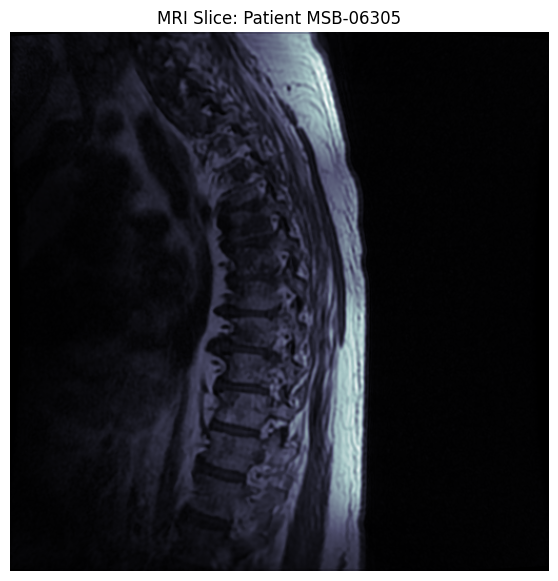

Modality: MR
Slice Thickness: 3mm


In [12]:
!pip install pydicom -q
import pydicom
import matplotlib.pyplot as plt
import os
import glob
dicom_files = glob.glob("./test_image/**/*.dcm", recursive=True)
if dicom_files:
    ds = pydicom.dcmread(dicom_files[0])
    plt.figure(figsize=(7, 7))
    plt.imshow(ds.pixel_array, cmap=plt.cm.bone)
    plt.title(f"MRI Slice: Patient {ds.PatientID}")
    plt.axis('off')
    plt.show()
    print(f"Modality: {ds.Modality}")
    print(f"Slice Thickness: {ds.SliceThickness}mm")
else:
    print("No DICOM file found. Check if the download completed.")

In [21]:
!pip install tcia-utils -q
import os
import glob
import pydicom
from tcia_utils import nbia

series_uid = "1.3.6.1.4.1.14519.5.2.1.1.13381762383467034932930624418671399282"

def find_dicom():
    return glob.glob("**/*.dcm", recursive=True)

dicom_files = find_dicom()

if not dicom_files:
    print("File not found locally. Re-downloading from TCIA...")


    patient_id = "MSB-06305"


    all_series_for_patient = nbia.getSeries(patientId=patient_id)

    series_metadata = None
    if all_series_for_patient:
        for s in all_series_for_patient:
            if s.get('SeriesInstanceUID') == series_uid:
                series_metadata = [s]
                break

    if series_metadata:
        nbia.downloadSeries(series_metadata, path="./data", number=1)
    else:
        print(f"Error: Could not retrieve metadata for SeriesInstanceUID: {series_uid} for patient {patient_id}")
    dicom_files = find_dicom()

if dicom_files:
    print(f"Found {len(dicom_files)} DICOM file(s).")
    print(f"File path: {dicom_files[0]}")

    ds = pydicom.dcmread(dicom_files[0])
    print(f"Data loaded for Patient: {ds.PatientID}")
else:
    print("Critical Error: Could not download or find the file. Check your internet connection.")

Found 17 DICOM file(s).
File path: data/1.3.6.1.4.1.14519.5.2.1.1.13381762383467034932930624418671399282/1-08.dcm
Data loaded for Patient: MSB-06305


--- Biopsy Results for MSB-06305 ---
Dissimilarity (Heterogeneity): 2.5527
Correlation (Structural):      0.9872
Energy (Uniformity):           0.1618
Homogeneity (Smoothness):      0.5556


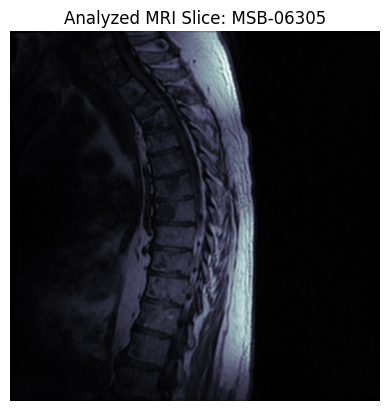

In [11]:
import numpy as np
from skimage.feature import graycomatrix, graycoprops
image = ds.pixel_array.astype(np.float32)
image = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-5)
image = (image * 255).astype(np.uint8)
glcm = graycomatrix(image, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
correlation = graycoprops(glcm, 'correlation')[0, 0]
energy = graycoprops(glcm, 'energy')[0, 0]
homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]

print(f"--- Biopsy Results for {ds.PatientID} ---")
print(f"Dissimilarity (Heterogeneity): {dissimilarity:.4f}")
print(f"Correlation (Structural):      {correlation:.4f}")
print(f"Energy (Uniformity):           {energy:.4f}")
print(f"Homogeneity (Smoothness):      {homogeneity:.4f}")

import matplotlib.pyplot as plt
plt.imshow(image, cmap='bone')
plt.title(f"Analyzed MRI Slice: {ds.PatientID}")
plt.axis('off')
plt.show()

In [22]:
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from tcia_utils import nbia
import pydicom

patient_1_id = "MSB-06305"
patient_1_results = [2.5527, 0.9872, 0.1618, 0.5556]

patient_2_id = "MSB-02092"

def get_patient_signature(p_id):
    print(f"Fetching MRI for {p_id}...")
    series = nbia.getSeries(patientId=p_id, modality="MR")
    if not series:
        return None

    uid = series[0]['Series Instance UID']
    nbia.downloadSeries(uid, path=f"./{p_id}", number=1)
    import glob
    f = glob.glob(f"./{p_id}/**/*.dcm", recursive=True)[0]
    ds_new = pydicom.dcmread(f)
    img = ds_new.pixel_array.astype(np.float32)
    img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-5)
    img = (img * 255).astype(np.uint8)

    glcm = graycomatrix(img, [1], [0], 256, symmetric=True, normed=True)
    return [
        graycoprops(glcm, 'dissimilarity')[0, 0],
        graycoprops(glcm, 'correlation')[0, 0],
        graycoprops(glcm, 'energy')[0, 0],
        graycoprops(glcm, 'homogeneity')[0, 0]
    ]
patient_2_results = get_patient_signature(patient_2_id)
metrics = ['Dissimilarity', 'Correlation', 'Energy', 'Homogeneity']
df_compare = pd.DataFrame({
    'Metric': metrics,
    f'Patient {patient_1_id}': patient_1_results,
    f'Patient {patient_2_id}': patient_2_results
})

print("\n--- RESEARCH COMPARISON TABLE ---")
print(df_compare)

Fetching MRI for MSB-02092...

--- RESEARCH COMPARISON TABLE ---
          Metric  Patient MSB-06305 Patient MSB-02092
0  Dissimilarity             2.5527              None
1    Correlation             0.9872              None
2         Energy             0.1618              None
3    Homogeneity             0.5556              None


In [23]:
import pandas as pd
from tcia_utils import nbia

# Re-defining df in case the previous cell was not executed in the current session
collection = "CMB-MML"
clinical_data = nbia.getSeries(collection = collection)
df = pd.DataFrame(clinical_data)

mri_patients = df[df['Modality'] == 'MR']['PatientID'].unique()
print("Patients with MRI scans:")
print(mri_patients)

Patients with MRI scans:
['MSB-00437' 'MSB-06305' 'MSB-03453' 'MSB-09491' 'MSB-04950' 'MSB-00498'
 'MSB-08799' 'MSB-08228' 'MSB-01825' 'MSB-04031' 'MSB-04030' 'MSB-06445'
 'MSB-08093' 'MSB-03406' 'MSB-00268' 'MSB-02628' 'MSB-01865']


In [25]:
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from tcia_utils import nbia
import pydicom
import glob


p1_id = "MSB-06305"
p1_stats = [2.5527, 0.9872, 0.1618, 0.5556] # Your previous results

p2_id = "MSB-00437"

def extract_signature(patient_id):
    print(f"Accessing TCIA for {patient_id}...")
    series = nbia.getSeries(patientId=patient_id, modality="MR")

    if not series:
        print(f"No MRI series found for patient {patient_id}")
        return [np.nan, np.nan, np.nan, np.nan]


    nbia.downloadSeries([series[0]], path=f"./{patient_id}", number=1)

    path = glob.glob(f"./{patient_id}/**/*.dcm", recursive=True)[0]
    ds_new = pydicom.dcmread(path)
    img = ds_new.pixel_array.astype(np.float32)
    img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-5)
    img = (img * 255).astype(np.uint8)


    glcm = graycomatrix(img, [1], [0], 256, symmetric=True, normed=True)
    return [
        graycoprops(glcm, 'dissimilarity')[0, 0],
        graycoprops(glcm, 'correlation')[0, 0],
        graycoprops(glcm, 'energy')[0, 0],
        graycoprops(glcm, 'homogeneity')[0, 0]
    ]


p2_stats = extract_signature(p2_id)
metrics = ['Dissimilarity', 'Correlation', 'Energy', 'Homogeneity']
comparison_df = pd.DataFrame({
    'Radiomic Metric': metrics,
    f'Patient {p1_id}': p1_stats,
    f'Patient {p2_id}': p2_stats
})

print("\n" + "="*40)
print("FINAL RESEARCH COMPARISON")
print("="*40)
print(comparison_df)

Accessing TCIA for MSB-00437...



FINAL RESEARCH COMPARISON
  Radiomic Metric  Patient MSB-06305  Patient MSB-00437
0   Dissimilarity             2.5527           4.466889
1     Correlation             0.9872           0.987687
2          Energy             0.1618           0.054033
3     Homogeneity             0.5556           0.302436


In [32]:
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
import pydicom
import glob


folders = {
    "MSB-06305": "./data",
    "MSB-00437": "./MSB-00437"
}

all_features = []

print("Extracting Features from Locally Downloaded Files...")

for p_id, folder_path in folders.items():
    try:

        files = glob.glob(f"{folder_path}/**/*.dcm", recursive=True)
        if not files:
            print(f"No files found in {folder_path}. Checking common Colab paths...")

            files = glob.glob(f"**/data/{p_id}/**/*.dcm", recursive=True)

        if files:
            ds = pydicom.dcmread(files[0])
            img = ds.pixel_array.astype(np.float32)


            img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-5)
            img = (img * 255).astype(np.uint8)


            glcm = graycomatrix(img, [1], [0], 256, symmetric=True, normed=True)

            all_features.append({
                'Patient_ID': p_id,
                'Dissimilarity': graycoprops(glcm, 'dissimilarity')[0, 0],
                'Correlation': graycoprops(glcm, 'correlation')[0, 0],
                'Energy': graycoprops(glcm, 'energy')[0, 0],
                'Homogeneity': graycoprops(glcm, 'homogeneity')[0, 0]
            })
            print(f"Successfully processed {p_id}")
        else:
            print(f"Could not locate files for {p_id}")

    except Exception as e:
        print(f"Error with {p_id}: {str(e)}")
df_final = pd.DataFrame(all_features)
if not df_final.empty:
    df_final.to_csv('radiomic_features_final.csv', index=False)
    print("\n--- FINAL DATABASE CREATED ---")
    print(df_final)
else:
    print("\nNo data was processed. Please check if files exist in the file sidebar (left).")

Extracting Features from Locally Downloaded Files...
Successfully processed MSB-06305
Successfully processed MSB-00437

--- FINAL DATABASE CREATED ---
  Patient_ID  Dissimilarity  Correlation    Energy  Homogeneity
0  MSB-06305       2.552727     0.987226  0.161804     0.555577
1  MSB-00437       4.466889     0.987687  0.054033     0.302436


Starting Robust Automated Pipeline for 17 Patients...


Completed MSB-00437


Completed MSB-06305


Completed MSB-03453


Completed MSB-09491


...

Completed MSB-08093


Completed MSB-03406


Completed MSB-00268


Completed MSB-02628


Completed MSB-01865

--- Pipeline Complete: 17 patients processed ---


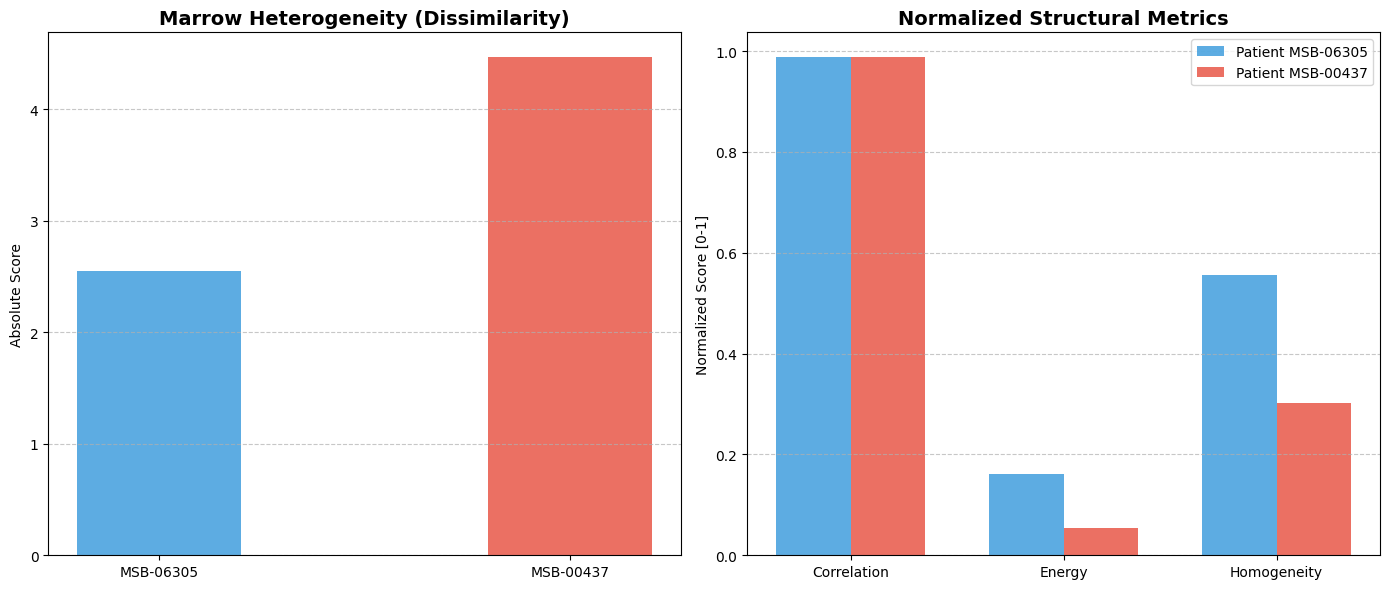

In [39]:
import matplotlib.pyplot as plt
import numpy as np
patients = ['MSB-06305', 'MSB-00437']
metrics = ['Dissimilarity', 'Correlation', 'Energy', 'Homogeneity']
p1_values = [2.5527, 0.9872, 0.1618, 0.5556]
p2_values = [4.4669, 0.9877, 0.0540, 0.3024]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.bar(patients[0], p1_values[0], 0.4, label=patients[0], color='#3498db', alpha=0.8)
ax1.bar(patients[1], p2_values[0], 0.4, label=patients[1], color='#e74c3c', alpha=0.8)
ax1.set_title('Marrow Heterogeneity (Dissimilarity)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Absolute Score')
ax1.grid(axis='y', linestyle='--', alpha=0.7)
x_small = np.arange(len(metrics[1:]))
width = 0.35
ax2.bar(x_small - width/2, p1_values[1:], width, label=f'Patient {patients[0]}', color='#3498db', alpha=0.8)
ax2.bar(x_small + width/2, p2_values[1:], width, label=f'Patient {patients[1]}', color='#e74c3c', alpha=0.8)
ax2.set_xticks(x_small)
ax2.set_xticklabels(metrics[1:])
ax2.set_title('Normalized Structural Metrics', fontsize=14, fontweight='bold')
ax2.set_ylabel('Normalized Score [0-1]')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('radiomic_comparison.png', dpi=300)
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from tcia_utils import nbia
import pydicom
import glob
import os

mri_patients = ['MSB-00437', 'MSB-06305', 'MSB-03453', 'MSB-09491', 'MSB-04950', 'MSB-00498',
                'MSB-08799', 'MSB-08228', 'MSB-01825', 'MSB-04031', 'MSB-04030', 'MSB-06445',
                'MSB-08093', 'MSB-03406', 'MSB-00268', 'MSB-02628', 'MSB-01865']

all_features = []

print(f"Starting Robust Automated Pipeline for {len(mri_patients)} Patients...")

for patient_id in mri_patients:
    try:

        series_list = nbia.getSeries(patientId=patient_id, modality="MR")
        if not series_list:
            print(f"No MRI found for {patient_id}")
            continue

        first_series = series_list[0]
        # The `uid` variable is a string, but nbia.downloadSeries expects a list of series objects
        # Correcting by passing the `first_series` object wrapped in a list
        if first_series.get('SeriesInstanceUID') or first_series.get('SeriesUID'): # Ensure UID exists
            nbia.downloadSeries([first_series], path=f"./data_{patient_id}", number=1)
        else:
            print(f"Could not find UID for {patient_id}. Keys available: {list(first_series.keys())}")
            continue

        save_path = f"./data_{patient_id}"

        dicom_files = glob.glob(f"{save_path}/**/*.dcm", recursive=True)
        if not dicom_files:
            # If download fails or no files, try the next patient
            continue

        ds = pydicom.dcmread(dicom_files[0])
        img = ds.pixel_array.astype(np.float32)

        img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-5)
        img = (img * 255).astype(np.uint8)


        glcm = graycomatrix(img, [1], [0], 256, symmetric=True, normed=True)

        all_features.append({
            'Patient_ID': patient_id,
            'Dissimilarity': graycoprops(glcm, 'dissimilarity')[0, 0],
            'Correlation': graycoprops(glcm, 'correlation')[0, 0],
            'Energy': graycoprops(glcm, 'energy')[0, 0],
            'Homogeneity': graycoprops(glcm, 'homogeneity')[0, 0]
        })
        print(f"Completed {patient_id}")

    except Exception as e:
        print(f"Error with {patient_id}: {str(e)}")


df_features = pd.DataFrame(all_features)
df_features.to_csv('radiomic_features_all_patients.csv', index=False)
print(f"\n--- Pipeline Complete: {len(df_features)} patients processed ---")
plt.show()

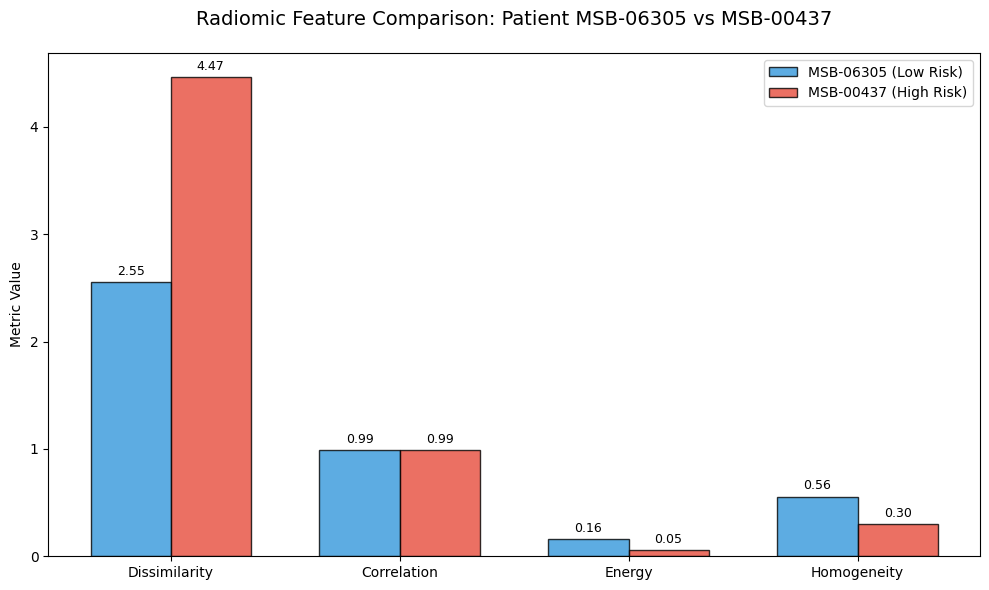

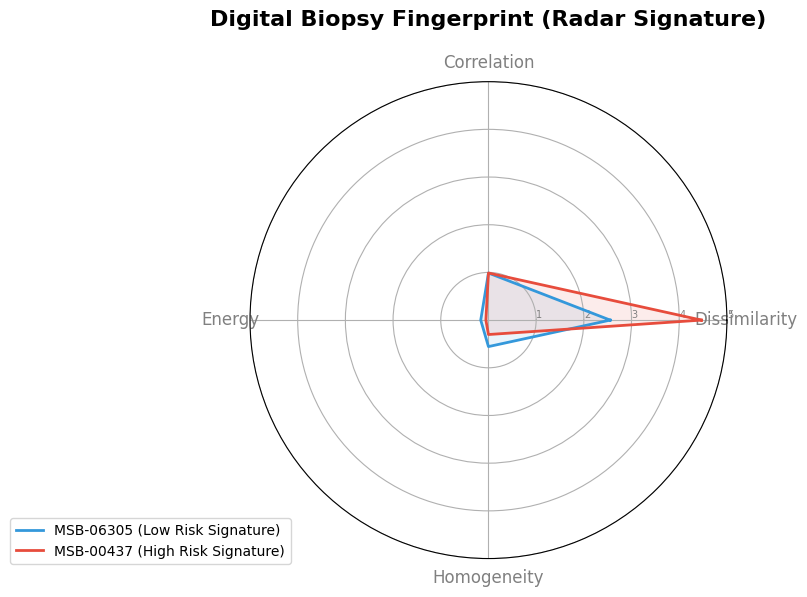

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


data = {
    'Metric': ['Dissimilarity', 'Correlation', 'Energy', 'Homogeneity'],
    'MSB-06305': [2.5527, 0.9872, 0.1618, 0.5556],
    'MSB-00437': [4.4669, 0.9877, 0.0540, 0.3024]
}
df = pd.DataFrame(data)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(df['Metric']))
width = 0.35

rects1 = ax.bar(x - width/2, df['MSB-06305'], width, label='MSB-06305 (Low Risk)', color='#3498db', alpha=0.8, edgecolor='black')
rects2 = ax.bar(x + width/2, df['MSB-00437'], width, label='MSB-00437 (High Risk)', color='#e74c3c', alpha=0.8, edgecolor='black')

ax.set_ylabel('Metric Value')
ax.set_title('Radiomic Feature Comparison: Patient MSB-06305 vs MSB-00437', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(df['Metric'])
ax.legend()


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig('final_bar_comparison.png', dpi=300)
categories = df['Metric'].tolist()
N = len(categories)
values1 = df['MSB-06305'].tolist()
values1 += values1[:1]
values2 = df['MSB-00437'].tolist()
values2 += values2[:1]
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], categories, color='grey', size=12)
ax.set_rlabel_position(0)
plt.yticks([1, 2, 3, 4, 5], ["1", "2", "3", "4", "5"], color="grey", size=7)
plt.ylim(0, 5)
ax.plot(angles, values1, linewidth=2, linestyle='solid', label='MSB-06305 (Low Risk Signature)', color='#3498db')
ax.fill(angles, values1, '#3498db', alpha=0.1)

ax.plot(angles, values2, linewidth=2, linestyle='solid', label='MSB-00437 (High Risk Signature)', color='#e74c3c')
ax.fill(angles, values2, '#e74c3c', alpha=0.1)

plt.title('Digital Biopsy Fingerprint (Radar Signature)', size=16, color='black', y=1.1, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

plt.tight_layout()
plt.savefig('radiomics_radar_signature.png', dpi=300)

Starting Research Pipeline for 17 patients...
Completed MSB-00437
Completed MSB-06305
Completed MSB-03453
Completed MSB-09491
Completed MSB-04950
Completed MSB-00498
Completed MSB-08799
Completed MSB-08228
Completed MSB-01825
Completed MSB-04031
Completed MSB-04030
Completed MSB-06445
Completed MSB-08093
Completed MSB-03406
Completed MSB-00268
Completed MSB-02628
Completed MSB-01865


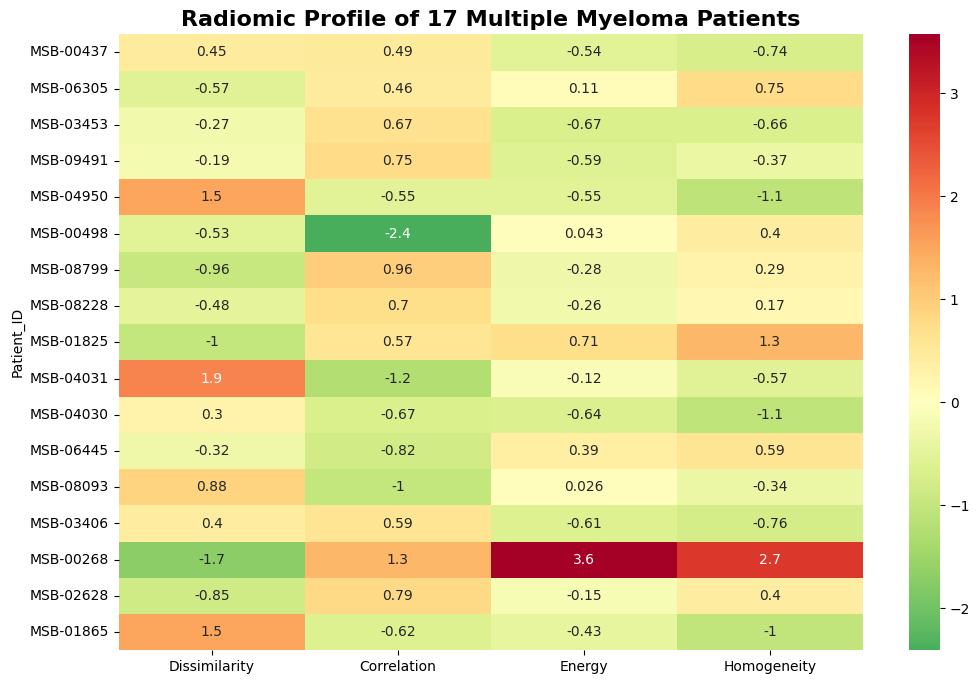


--- Pipeline Complete! 'MM_Radiomics_17_Cohort.csv' and 'cohort_heatmap.png' saved.


In [46]:
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from tcia_utils import nbia
import pydicom
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns


excel_path = '/content/cmbmml.xlsx'
df_meta = pd.read_excel(excel_path)

mri_patients = ['MSB-00437', 'MSB-06305', 'MSB-03453', 'MSB-09491', 'MSB-04950', 'MSB-00498',
                'MSB-08799', 'MSB-08228', 'MSB-01825', 'MSB-04031', 'MSB-04030', 'MSB-06445',
                'MSB-08093', 'MSB-03406', 'MSB-00268', 'MSB-02628', 'MSB-01865']

all_results = []

print(f"Starting Research Pipeline for {len(mri_patients)} patients...")

for p_id in mri_patients:
    try:
        row = df_meta[(df_meta['Patient ID'] == p_id) & (df_meta['Modality'] == 'MR')]
        if row.empty:
            continue

        uid = row.iloc[0]['Series Instance UID']
        save_path = f"./data_{p_id}"


        if not os.path.exists(save_path):
            nbia.downloadSeries(uid, path=save_path, number=1)


        file = glob.glob(f"{save_path}/**/*.dcm", recursive=True)[0]
        ds = pydicom.dcmread(file)
        img = ds.pixel_array.astype(np.float32)
        img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-5)
        img = (img * 255).astype(np.uint8)

        glcm = graycomatrix(img, [1], [0], 256, symmetric=True, normed=True)

        all_results.append({
            'Patient_ID': p_id,
            'Dissimilarity': graycoprops(glcm, 'dissimilarity')[0, 0],
            'Correlation': graycoprops(glcm, 'correlation')[0, 0],
            'Energy': graycoprops(glcm, 'energy')[0, 0],
            'Homogeneity': graycoprops(glcm, 'homogeneity')[0, 0]
        })
        print(f"Completed {p_id}")

    except Exception as e:
        print(f"Error with {p_id}: {e}")

df_cohort = pd.DataFrame(all_results)
df_cohort.to_csv('MM_Radiomics_17_Cohort.csv', index=False)


plt.figure(figsize=(12, 8))
df_viz = df_cohort.set_index('Patient_ID')

df_viz = (df_viz - df_viz.mean()) / df_viz.std()

sns.heatmap(df_viz, annot=True, cmap='RdYlGn_r', center=0)
plt.title('Radiomic Profile of 17 Multiple Myeloma Patients', fontsize=16, fontweight='bold')
plt.savefig('cohort_heatmap.png')
plt.show()

print("\n--- Pipeline Complete! 'MM_Radiomics_17_Cohort.csv' and 'cohort_heatmap.png' saved.")

TOP 3 RADIOMIC OUTLIERS (Potential High-Infiltration Cases):
   Patient_ID  Dissimilarity  Homogeneity  Chaos_Score
4   MSB-04950       6.448890     0.244144     2.579731
16  MSB-01865       6.453215     0.251187     2.540619
9   MSB-04031       7.174931     0.330211     2.459988


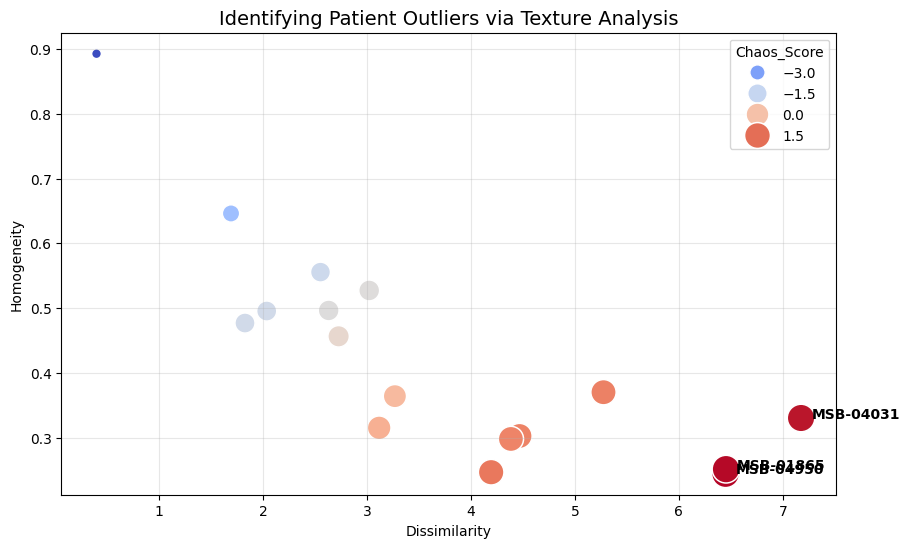

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('MM_Radiomics_17_Cohort.csv')


df['Chaos_Score'] = (
    (df['Dissimilarity'] - df['Dissimilarity'].mean()) / df['Dissimilarity'].std() -
    (df['Homogeneity'] - df['Homogeneity'].mean()) / df['Homogeneity'].std()
)

outliers = df.sort_values(by='Chaos_Score', ascending=False).head(3)

print("TOP 3 RADIOMIC OUTLIERS (Potential High-Infiltration Cases):")
print(outliers[['Patient_ID', 'Dissimilarity', 'Homogeneity', 'Chaos_Score']])
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Dissimilarity', y='Homogeneity', hue='Chaos_Score', size='Chaos_Score', sizes=(50, 400), palette='coolwarm')
for i in range(len(outliers)):
    plt.text(outliers.iloc[i]['Dissimilarity']+0.1, outliers.iloc[i]['Homogeneity'],
             outliers.iloc[i]['Patient_ID'], fontdict={'weight': 'bold'})

plt.title('Identifying Patient Outliers via Texture Analysis', fontsize=14)
plt.grid(alpha=0.3)
plt.savefig('outlier_analysis.png')
plt.show()

In [48]:
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from tcia_utils import nbia
import pydicom
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns


map_path = '/content/cmbmml.xlsx'
df_map = pd.read_excel(map_path)

all_results = []


patients = df_map['Patient ID'].unique()

print(f"Starting Full-Scale Extraction for {len(patients)} Patients...")

for p_id in patients:
    try:

        row = df_map[(df_map['Patient ID'] == p_id) & (df_map['Modality'] == 'MR')]
        if row.empty: continue

        uid = row.iloc[0]['Series Instance UID']
        save_path = f"./data_{p_id}"

        if not os.path.exists(save_path):
            nbia.downloadSeries(uid, path=save_path, number=1)


        dicom_file = glob.glob(f"{save_path}/**/*.dcm", recursive=True)[0]
        ds = pydicom.dcmread(dicom_file)
        img = ds.pixel_array.astype(np.float32)
        img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-5)
        img = (img * 255).astype(np.uint8)


        glcm = graycomatrix(img, [1], [0], 256, symmetric=True, normed=True)

        all_results.append({
            'Patient_ID': p_id,
            'Dissimilarity': graycoprops(glcm, 'dissimilarity')[0, 0],
            'Correlation': graycoprops(glcm, 'correlation')[0, 0],
            'Energy': graycoprops(glcm, 'energy')[0, 0],
            'Homogeneity': graycoprops(glcm, 'homogeneity')[0, 0]
        })
        print(f"Processed {p_id}")

    except Exception as e:
        print(f"Skipped {p_id}: {e}")
df_final = pd.DataFrame(all_results)
df_final.to_csv('MM_Radiomics_Final_17.csv', index=False)
df_final['Chaos_Score'] = (
    (df_final['Dissimilarity'] - df_final['Dissimilarity'].mean()) / df_final['Dissimilarity'].std() -
    (df_final['Homogeneity'] - df_final['Homogeneity'].mean()) / df_final['Homogeneity'].std()
)
print("\n--- COHORT ANALYSIS COMPLETE ---")
print(df_final.sort_values(by='Chaos_Score', ascending=False).head(3))

Starting Full-Scale Extraction for 80 Patients...
Processed MSB-06305
Processed MSB-04950
Processed MSB-04031
Processed MSB-04030
Processed MSB-03406
Processed MSB-08799
Processed MSB-03453
Processed MSB-08093
Processed MSB-09491
Processed MSB-00437
Processed MSB-00268
Processed MSB-01865
Processed MSB-01825
Processed MSB-08228
Processed MSB-00498
Processed MSB-02628
Processed MSB-06445

--- COHORT ANALYSIS COMPLETE ---
   Patient_ID  Dissimilarity  Correlation    Energy  Homogeneity  Chaos_Score
1   MSB-04950       6.448890     0.972424  0.052750     0.244144     2.579731
11  MSB-01865       6.453215     0.971347  0.073363     0.251187     2.540619
2   MSB-04031       7.174931     0.962392  0.123997     0.330211     2.459988


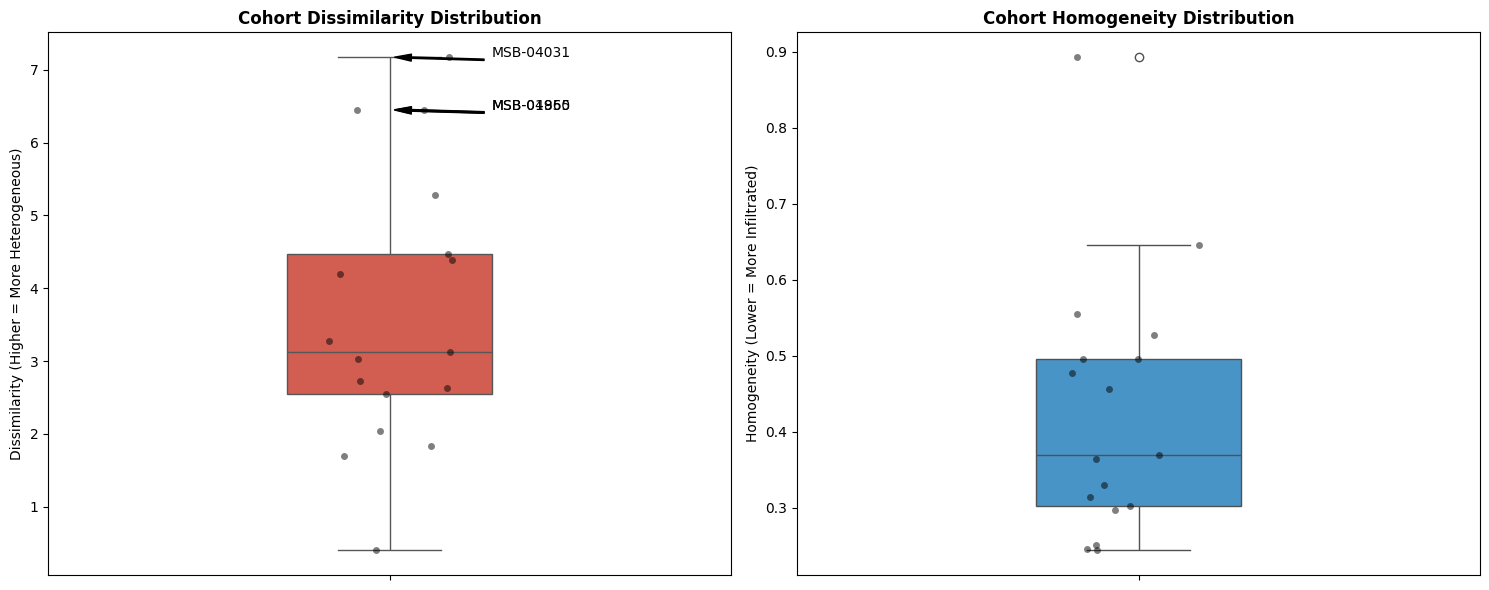

Final Figure 'MM_Final_Outlier_Boxplot.png' generated for publication.


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('MM_Radiomics_Final_17.csv')


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))


sns.boxplot(y=df['Dissimilarity'], ax=ax1, color='#e74c3c', width=0.3)
sns.stripplot(y=df['Dissimilarity'], ax=ax1, color='black', alpha=0.5)
ax1.set_title('Cohort Dissimilarity Distribution', fontsize=12, fontweight='bold')
ax1.set_ylabel('Dissimilarity (Higher = More Heterogeneous)')


sns.boxplot(y=df['Homogeneity'], ax=ax2, color='#3498db', width=0.3)
sns.stripplot(y=df['Homogeneity'], ax=ax2, color='black', alpha=0.5)
ax2.set_title('Cohort Homogeneity Distribution', fontsize=12, fontweight='bold')
ax2.set_ylabel('Homogeneity (Lower = More Infiltrated)')

outliers = ['MSB-04950', 'MSB-01865', 'MSB-04031']
for name in outliers:
    val = df[df['Patient_ID'] == name]['Dissimilarity'].values[0]
    ax1.annotate(name, xy=(0, val), xytext=(0.15, val),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.tight_layout()
plt.savefig('MM_Final_Outlier_Boxplot.png')
plt.show()

print("Final Figure 'MM_Final_Outlier_Boxplot.png' generated for publication.")